In [ ]:
import cv2

filename='DSC_0675'
img_in = f'../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/delivery_area/images/dslr_images_undistorted/{filename}.JPG'
img = cv2.imread(img_in)
img2 = cv2.resize(img,(512,384))
img = torch.from_numpy(img2,dtype=torch.uint8)

ModuleNotFoundError: No module named 'cv2'

In [3]:
import torch

#data = torch.load('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/random_walks/rw_1_0.pt',weights_only=False)
#data = torch.load('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/rw_latents/z_img/rw_1_0.pt',weights_only=False)
data = torch.load('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/rw_latents/z_img_rw_1.pt')
print(data)
ei = data.edge_index

Data(x=[40, 128], edge_attr=[182], edge_index=[2, 182])


In [2]:
import torch

data = torch.load('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/combined_dataset/DSC_0675.pt',weights_only=False)
print(data['img'].shape,data['edge_index'].shape,data['edge_weights'].shape,data['pcd'].shape,data['vis'].shape)

ModuleNotFoundError: No module named 'torch'

In [2]:
import pandas as pd
query_name = 'DSC_0675'
stats_2d_csv = pd.read_csv('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/vis_2d_camera.csv')
stats_3d_csv = pd.read_csv('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/vis_3d_camera.csv')
vals_2d = stats_2d_csv.loc[stats_2d_csv['img']==query_name,['area_calc','mean_dist','max_dist','min_dist','dist_std']]
vals_3d = stats_3d_csv.loc[stats_3d_csv['img']==query_name,['vol_calc','mean_dist','max_dist','min_dist','dist_std']]
a = torch.tensor(vals_2d.to_numpy(dtype=float), dtype=torch.float32)
b = torch.tensor(vals_3d.to_numpy(dtype=float), dtype=torch.float32)
vis = torch.cat([a, b], dim=1)

In [1]:
import open3d as o3d

pcd = o3d.io.read_point_cloud('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/delivery_area/scan_raw/combined_aligned.ply')
radii = [0.005, 0.01, 0.02, 0.04]
mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
    pcd, o3d.utility.DoubleVector(radii))
o3d.io.write_triangle_mesh('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/anlieferung/delivery_area/scan_raw/mesh.ply',mesh)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


RuntimeError: [1;31m[Open3D Error] (std::shared_ptr<open3d::geometry::TriangleMesh> open3d::geometry::{anonymous}::BallPivoting::Run(const std::vector<double>&)) /root/Open3D/cpp/open3d/geometry/SurfaceReconstructionBallPivoting.cpp:659: ReconstructBallPivoting requires normals
[0;m

In [5]:
import torch

data = torch.load('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/rw_latents/z_img/rw_1_0.pt',weights_only=False)
print(data)

{'latent': tensor([[ 2.5125e-02, -1.6020e-02,  1.6653e+00, -3.9460e-03,  1.2280e-02,
          1.8441e-02,  5.0722e-03,  3.5443e-02, -1.2609e-03, -4.2371e-03,
          1.0102e-02, -1.5168e+00,  5.8512e-03,  8.1711e-04, -5.1118e-02,
          1.5814e-01,  3.7826e+00, -6.4012e-03,  2.8299e+00,  9.5089e-03,
          5.9253e-01,  9.3500e-03, -1.0215e+00, -3.2623e-02,  2.7027e+00,
          2.5483e-03,  1.8359e-02, -1.8610e-02, -1.4986e-02,  3.6045e-02,
          1.9702e-02,  3.3447e-03, -1.5211e-02,  2.1842e-02,  1.8575e-02,
         -5.6233e-03,  2.5725e+00,  1.5495e-03, -1.3269e-02,  1.2085e-02,
          1.6150e-02,  4.8777e-03, -1.5774e-02, -1.6810e-02,  1.6662e+00,
         -1.5102e-02, -8.7038e-03, -1.9356e+00, -3.1340e-03, -5.1991e-01,
          2.9510e-03, -4.6635e+00, -1.2879e-02,  5.5297e-01, -3.8201e+00,
         -3.5111e+00, -1.3379e-02,  1.2639e-02,  1.8071e-02, -1.3262e-03,
          3.9738e-02, -4.8998e-03,  1.2416e-02,  1.8742e-02, -1.2637e+00,
          6.2693e-03,  4.01

DataBatch(latent=[16, 128], loc=[16, 3], viewdir=[16, 3])
torch.return_types.min(
values=tensor([1.0771, 0.6272, 0.6084, 0.1797, 0.1797, 2.8013, 0.2169, 2.0515, 0.2641,
        0.6084, 2.0515, 0.6272, 0.2641, 1.5842, 1.9213, 0.2169],
       dtype=torch.float64),
indices=tensor([ 8, 11,  9,  4,  3,  9, 15, 10, 12,  2,  7,  1,  8,  3,  4,  6]))
tensor([[ 0,  8],
        [ 1, 11],
        [ 2,  9],
        [ 3,  4],
        [ 4,  3],
        [ 5,  9],
        [ 6, 15],
        [ 7, 10],
        [ 8, 12],
        [ 9,  2],
        [10,  7],
        [11,  1],
        [12,  8],
        [13,  3],
        [14,  4],
        [15,  6]])
torch.Size([16])


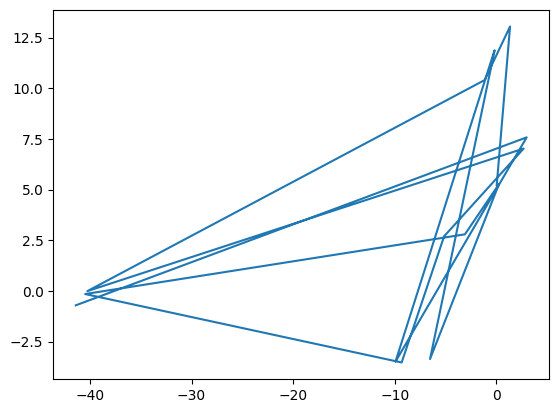

In [19]:
from preprocessing_src.dataloader_walk import make_loader_walk
from preprocessing_src.dataloader_subgraph import make_loader_subgraph
import torch
import matplotlib.pyplot as plt

device = torch.device('cpu')

cluster_loader = make_loader_subgraph("../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/scan_pcd_graph/clusters/", pattern="*.pt", batch_size=4, shuffle=True, num_workers=4)
walk_loader = make_loader_walk('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/rw_latents/z_img', batch_size=16, shuffle=True, num_workers=4)

for part in cluster_loader:
    part = part.to(device)
    #mean_xyz = part.pos.mean(dim=0)
    for walk in walk_loader:
        walk = walk.to(device)
        locs = walk['loc']
        print(walk)#,walk['viewdir'])
        plt.plot(walk['loc'][:,0],walk['loc'][:,1])
        # ground truth distances: center of each cluster xyz - vantage point translation
        #print(walk,type(walk))
        dist = torch.cdist(locs, locs)
        dist.fill_diagonal_(1e6)
        print(dist.min(dim=1))
        dist_pairs = torch.stack([torch.arange(0,dist.shape[0]),dist.min(dim=1).indices],dim=1)
        print(dist_pairs)
        t1, v1 = walk['loc'][dist_pairs], walk['viewdir'][dist_pairs] # B, 2, 3
        tx1, ty1, tz1, tx2, ty2, tz2, u1, v1, w1, u2, v2, w2 = t1[:,0,0],t1[:,0,1],t1[:,0,2],t1[:,1,0],t1[:,1,1],t1[:,1,2],v1[:,0,0],v1[:,0,1],v1[:,0,2],v1[:,1,0],v1[:,1,1],v1[:,1,2]
        print(tx1.shape)
        break
    break

/tmp/ipykernel_191598/1309170426.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(data.pos.mean(dim=0)[0],data.pos.mean(dim=0)[1],c=(0,0,0),s=0.2)


{'graph': DataBatch(pos=[1224, 3], rgb=[1224, 3], x=[1224, 6], edge_attr=[43962], edge_index=[2, 43962], batch=[1224], ptr=[2]), 'graph_idx': tensor([82]), 'neighbor_idx': tensor([[37, 54, 49, 12, 92]]), 'neighbor_graphs': DataBatch(pos=[6110, 3], rgb=[6110, 3], x=[6110, 6], edge_attr=[211492], edge_index=[2, 211492], batch=[6110], ptr=[6])}


/tmp/ipykernel_191598/1309170426.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(pos_n.mean(dim=0)[0],pos_n.mean(dim=0)[1],c=(0,0,1),s=2)
/tmp/ipykernel_191598/1309170426.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(pos_per_graph[i].mean(dim=0)[0],pos_per_graph[i].mean(dim=0)[1],c=(1,0,0),s=1)


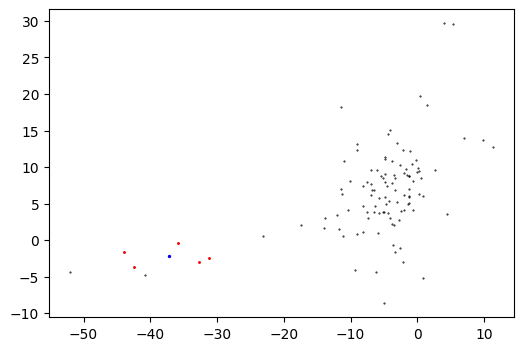

In [4]:
import torch
from preprocessing_src.dataloader_partial import make_loader_partial
import matplotlib.pyplot as plt
import glob

graph_loader = make_loader_partial("../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/scan_pcd_graph/clusters/", pattern="*.pt", batch_size=1, shuffle=True, num_workers=4)

plt.figure(figsize=(6,4))
files = glob.glob("../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/scan_pcd_graph/clusters/*.pt")
for file in files:
    data = torch.load(file)
    plt.scatter(data.pos.mean(dim=0)[0],data.pos.mean(dim=0)[1],c=(0,0,0),s=0.2)


for graph in graph_loader:
    print(graph)
    pos = graph['neighbor_graphs'].pos
    ptr = graph['neighbor_graphs'].ptr
    pos_n = graph['neighbor_graphs'].pos
    ptr_n = graph['neighbor_graphs'].ptr
    plt.scatter(pos_n.mean(dim=0)[0],pos_n.mean(dim=0)[1],c=(0,0,1),s=2)

    pos_per_graph = []
    for i in range(len(ptr) - 1):
        start = ptr[i].item()
        end = ptr[i+1].item()
        pos_i = pos[start:end]
        pos_per_graph.append(pos_i)
    
    for i in range(len(ptr) - 1):
        plt.scatter(pos_per_graph[i].mean(dim=0)[0],pos_per_graph[i].mean(dim=0)[1],c=(1,0,0),s=1)
    break

{'img': tensor([[[0.4000, 0.3765, 0.3843],
         [0.3843, 0.3608, 0.3686],
         [0.4000, 0.3608, 0.3725],
         ...,
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000]],

        [[0.3451, 0.3216, 0.3294],
         [0.5451, 0.5451, 0.5490],
         [0.3882, 0.3529, 0.3686],
         ...,
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000]],

        [[0.3451, 0.3176, 0.3255],
         [0.3412, 0.3176, 0.3294],
         [0.3804, 0.3451, 0.3647],
         ...,
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000]],

        ...,

        [[0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000],
         [0.4157, 0.3608, 0.3294],
         ...,
         [0.3020, 0.2510, 0.2745],
         [0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000],
         [0.4157, 0.3647, 0.3294],
    

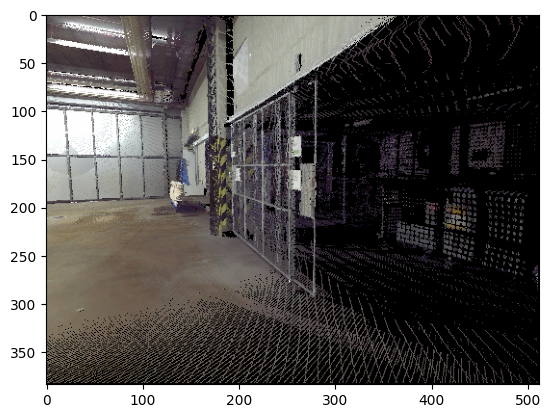

In [9]:
import torch
import matplotlib.pyplot as plt

data = torch.load('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/random_walks/rw_1_10.pt')
print(data)
plt.imshow(data['img'])